# **Introducción**

El objetivo de este análisis fue apoyar al Sr. Juan en la toma de decisión sobre qué tienda de la cadena Alura Store debería vender para iniciar un nuevo emprendimiento. Para ello, se evaluaron cinco aspectos principales: ingresos totales, ventas por categoría, valoración promedio de clientes, productos más y menos vendidos y costo de envío promedio (considerando que el cliente paga el envío). Los hallazgos se respaldan con métricas y visualizaciones generadas en el notebook.

# **Desarrollo y hallazgos**

### Importación de datos



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


###1. Análisis de facturación



In [2]:
# Ingreso total por tienda (sumando columna "Precio")

# (Opcional pero recomendado) asegurar que Precio sea numérico
for df in [tienda, tienda2, tienda3, tienda4]:
    df["Precio"] = pd.to_numeric(df["Precio"], errors="coerce")

ingreso_tienda_1 = tienda["Precio"].sum()
ingreso_tienda_2 = tienda2["Precio"].sum()
ingreso_tienda_3 = tienda3["Precio"].sum()
ingreso_tienda_4 = tienda4["Precio"].sum()

ingresos = pd.Series({
    "Tienda 1": ingreso_tienda_1,
    "Tienda 2": ingreso_tienda_2,
    "Tienda 3": ingreso_tienda_3,
    "Tienda 4": ingreso_tienda_4
}).sort_values(ascending=False)

ingresos


,0
Tienda 1,1.150880e+09
Tienda 2,1.116344e+09
Tienda 3,1.098020e+09
Tienda 4,1.038376e+09


1) Ingresos totales por tienda

Los ingresos totales estimados (suma de la columna Precio) mostraron el siguiente orden:

Tienda 1: 1.150880e+09

Tienda 2: 1.116344e+09

Tienda 3: 1.098020e+09

Tienda 4: 1.038376e+09

Interpretación: La Tienda 4 presenta el menor ingreso total de las cuatro, lo cual es una señal inicial de menor desempeño financiero comparativo.

### 2. Ventas por categoría

In [7]:
# Crear DataFrame con ventas por categoría de todas las tiendas

ventas_categoria = pd.DataFrame({
    "Tienda 1": ventas_categoria_t1,
    "Tienda 2": ventas_categoria_t2,
    "Tienda 3": ventas_categoria_t3,
    "Tienda 4": ventas_categoria_t4
}).fillna(0)

ventas_categoria


,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Categoría del Producto,,,,
Artículos para el hogar,171,181,177,201
Deportes y diversión,284,275,277,277
Electrodomésticos,312,305,278,254
Electrónicos,448,422,451,451
Instrumentos musicales,182,224,177,170
Juguetes,324,313,315,338
Libros,173,197,185,187
Muebles,465,442,499,480


<Figure size 1000x600 with 0 Axes>

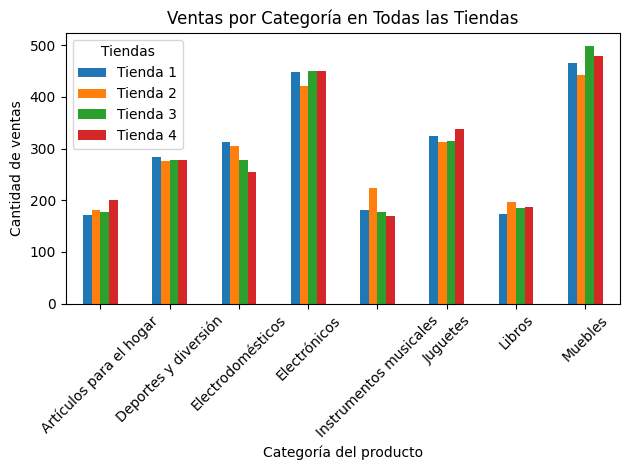

In [8]:
plt.figure(figsize=(10,6))
ventas_categoria.plot(kind="bar")
plt.title("Ventas por Categoría en Todas las Tiendas")
plt.xlabel("Categoría del producto")
plt.ylabel("Cantidad de ventas")
plt.xticks(rotation=45)
plt.legend(title="Tiendas")
plt.tight_layout()
plt.show()

2) Ventas por categoría (diversificación de demanda)

La distribución de ventas por categoría permite observar el perfil de consumo por tienda. En general, las categorías con mayor volumen en toda la cadena fueron Muebles y Electrónicos (con valores altos en todas las tiendas). Particularmente:

Tienda 3 lidera en Muebles (499), seguida por Tienda 4 (480).

Tienda 4 destaca en Artículos para el hogar (201) y Juguetes (338), pero queda por debajo de Tienda 3 en Muebles y no supera a Tienda 3 en valoración.

Interpretación: En términos de categorías, la Tienda 4 no muestra una ventaja clara que compense su menor facturación. Aunque tiene buen volumen en algunas categorías, su desempeño global no sobresale frente a las demás.

### 3. Calificación promedio de la tienda


In [12]:
# Asegurar que la columna de reseñas sea numérica
for df in [tienda, tienda2, tienda3, tienda4]:
    df["Calificación"] = pd.to_numeric(df["Calificación"], errors="coerce")

# Calificación promedio por tienda
valoraciones = pd.Series({
    "Tienda 1": tienda["Calificación"].mean(),
    "Tienda 2": tienda2["Calificación"].mean(),
    "Tienda 3": tienda3["Calificación"].mean(),
    "Tienda 4": tienda4["Calificación"].mean()
})

valoraciones


,0
Tienda 1,3.976685
Tienda 2,4.037304
Tienda 3,4.048326
Tienda 4,3.995759


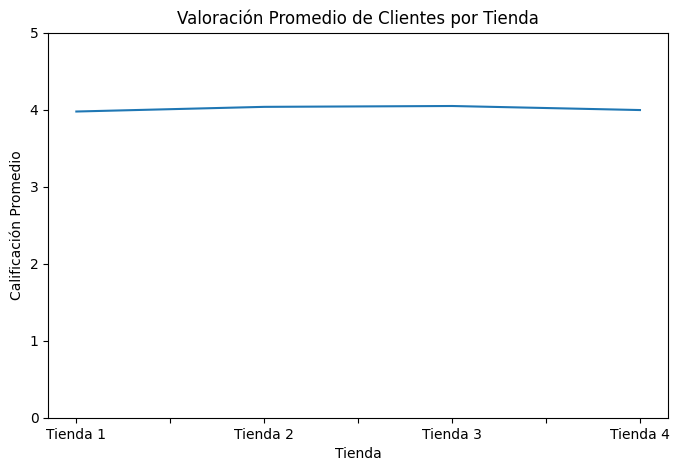

In [21]:
plt.figure(figsize=(8,5))
valoraciones.plot(kind="line")
plt.title("Valoración Promedio de Clientes por Tienda")
plt.xlabel("Tienda")
plt.ylabel("Calificación Promedio")
plt.ylim(0,5)
plt.show()

3) Valoración promedio de clientes (satisfacción)

Las calificaciones promedio fueron:

Tienda 1: 3.976685

Tienda 2: 4.037304

Tienda 3: 4.048326

Tienda 4: 3.995759

Interpretación: La Tienda 1 es la de menor valoración, pero la Tienda 4 se mantiene por debajo de Tienda 2 y Tienda 3. Es decir, no es la peor en satisfacción, pero tampoco está en el grupo con mejor percepción (Tiendas 2 y 3).

### 4. Productos más y menos vendidos

In [14]:
# Conteo de productos vendidos por tienda
productos_t1 = tienda["Producto"].value_counts()
productos_t2 = tienda2["Producto"].value_counts()
productos_t3 = tienda3["Producto"].value_counts()
productos_t4 = tienda4["Producto"].value_counts()

In [15]:
resumen_productos = pd.DataFrame({
    "Producto más vendido": [
        productos_t1.idxmax(),
        productos_t2.idxmax(),
        productos_t3.idxmax(),
        productos_t4.idxmax()
    ],
    "Ventas más altas": [
        productos_t1.max(),
        productos_t2.max(),
        productos_t3.max(),
        productos_t4.max()
    ],
    "Producto menos vendido": [
        productos_t1.idxmin(),
        productos_t2.idxmin(),
        productos_t3.idxmin(),
        productos_t4.idxmin()
    ],
    "Ventas más bajas": [
        productos_t1.min(),
        productos_t2.min(),
        productos_t3.min(),
        productos_t4.min()
    ]
}, index=["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"])

resumen_productos

,Producto más vendido,Ventas más altas,Producto menos vendido,Ventas más bajas
Tienda 1,Microondas,60,Auriculares con micrófono,33
Tienda 2,Iniciando en programación,65,Juego de mesa,32
Tienda 3,Kit de bancas,57,Bloques de construcción,35
Tienda 4,Cama box,62,Guitarra eléctrica,33


<Figure size 1200x600 with 0 Axes>

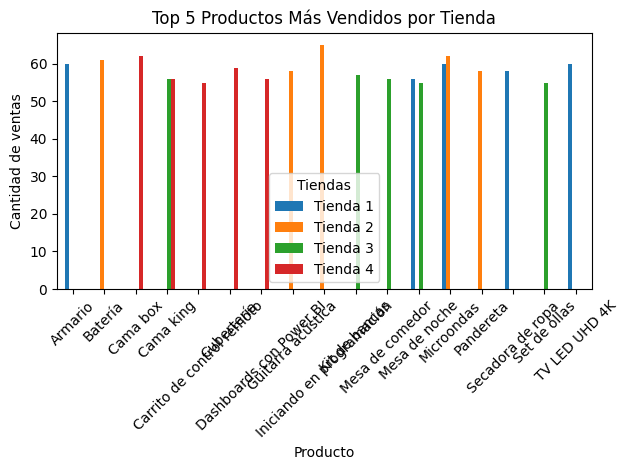

In [16]:
productos_top = pd.DataFrame({
    "Tienda 1": productos_t1.head(5),
    "Tienda 2": productos_t2.head(5),
    "Tienda 3": productos_t3.head(5),
    "Tienda 4": productos_t4.head(5)
}).fillna(0)

plt.figure(figsize=(12,6))
productos_top.plot(kind="bar")
plt.title("Top 5 Productos Más Vendidos por Tienda")
plt.xlabel("Producto")
plt.ylabel("Cantidad de ventas")
plt.xticks(rotation=45)
plt.legend(title="Tiendas")
plt.tight_layout()
plt.show()

4) Productos más vendidos y menos vendidos

Resumen por tienda:

Tienda 1: más vendido Microondas (60) / menos vendido Auriculares con micrófono (33)

Tienda 2: más vendido Iniciando en programación (65) / menos vendido Juego de mesa (32)

Tienda 3: más vendido Kit de bancas (57) / menos vendido Bloques de construcción (35)

Tienda 4: más vendido Cama box (62) / menos vendido Guitarra eléctrica (33)

Interpretación: Las tiendas presentan productos “estrella” con volúmenes similares; no se observa que la Tienda 4 tenga un producto líder lo suficientemente dominante como para justificar su menor ingreso total. El comportamiento de “menos vendidos” también es comparable con las demás tiendas.

### 5. Envío promedio por tienda

In [17]:
# Asegurar que el costo de envío sea numérico
for df in [tienda, tienda2, tienda3, tienda4]:
    df["Costo de envío"] = pd.to_numeric(df["Costo de envío"], errors="coerce")

# Costo de envío promedio por tienda
envio_promedio = pd.Series({
    "Tienda 1": tienda["Costo de envío"].mean(),
    "Tienda 2": tienda2["Costo de envío"].mean(),
    "Tienda 3": tienda3["Costo de envío"].mean(),
    "Tienda 4": tienda4["Costo de envío"].mean()
})

envio_promedio

,0
Tienda 1,26018.609580
Tienda 2,25216.235693
Tienda 3,24805.680373
Tienda 4,23459.457167


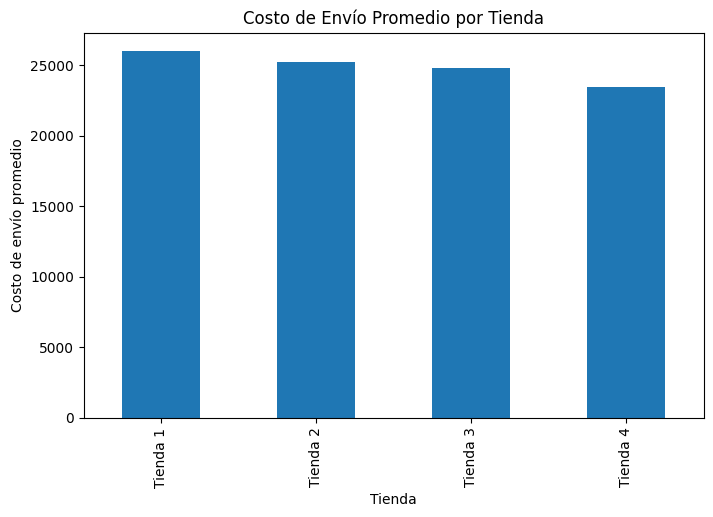

In [20]:
plt.figure(figsize=(8,5))
envio_promedio.plot(kind="bar")
plt.title("Costo de Envío Promedio por Tienda")
plt.xlabel("Tienda")
plt.ylabel("Costo de envío promedio")
plt.show()

5) Costo de envío promedio

Los costos promedio fueron:

Tienda 1: 26018.609580

Tienda 2: 25216.235693

Tienda 3: 24805.680373

Tienda 4: 23459.457167

Interpretación: La Tienda 4 tiene el menor costo de envío promedio, lo cual es positivo (porque el cliente paga el envío). Sin embargo, este factor por sí solo no compensa su menor ingreso total, especialmente considerando que su valoración promedio tampoco es la más alta.

#Conclusiones

Con base en los datos analizados y las visualizaciones generadas, se recomienda que el Sr. Juan venda la Tienda 4.

Justificación:

La Tienda 4 presenta el menor ingreso total (1.038376e+09), lo que indica el rendimiento financiero más bajo dentro de la cadena.

Aunque tiene un costo de envío promedio menor (23459.457167), este aspecto no se refleja en un mejor desempeño general de ingresos.

En valoración promedio, la Tienda 4 no es la peor, pero tampoco se encuentra entre las mejores (Tiendas 2 y 3), por lo que no aporta una ventaja clara en satisfacción del cliente.

En cuanto a categorías y productos más vendidos, no se observa una fortaleza diferencial que la haga destacar frente a las demás tiendas.

En síntesis, la Tienda 4 combina el peor desempeño de ingresos con métricas competitivas pero no sobresalientes en satisfacción y mix de productos. Por ello, resulta la opción más razonable para vender y liberar recursos para el nuevo emprendimiento.